In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
two_levels_up = os.path.dirname(os.path.dirname(os.getcwd()))
parent_directory = two_levels_up#os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(os.path.dirname(os.getcwd()))

from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params
from detection_criteria import mag
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from plot_hist import *
import pyarrow.dataset as ds
from filter_df import prepare_and_compute_metrics

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [2]:
labelsparams = lambda p: labels[p]
label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'

label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}
CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
                 r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
label_rmet_lat = [r"$\frac{RB(\pi_E)_{Roman+Rubin}}{RB(\pi_E)_{Roman}}$", r"$\frac{SB(\pi_E)_{Roman+Rubin}}{SB(\pi_E)_{Roman}}$", 
                 r"$\frac{NU(\pi_E)_{Roman+Rubin}}{NU(\pi_E)_{Roman}}$"]

dict_cat_peak = {"A":"peak in Rubin+Roman",
                "B":"peak in Rubin",
                "C":"peak in Roman"}

param_names = ['u0', 'tE', 'piE','piEE','piEN']
param_labels = [r'$\log_{10}(u_0)$', r'$t_E [day]$', r'$\log_{10}(\pi_E)$', r'$\log_{10}(|\pi_{EE}|)$',r'$\log_{10}(|\pi_{EN}|)$']

ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
      'i': 27.85, 'z': 27.46, 'y': 26.68}


In [3]:
model = 'FSPL'
path= parent_directory+f'/all_results/{"FFP"}/'
fit_rr = pd.read_parquet(path+"/fit_rr.parquet")
fit_roman =  pd.read_parquet(path+"/fit_roman.parquet")
# true = pd.read_parquet(path+"/true.parquet")

dataset_true = ds.dataset(parent_directory+"/all_results/data_FFP/true_ds/", format="parquet", partitioning="hive")
dataset_fit_rr = ds.dataset(parent_directory+"/all_results/data_FFP/fit_rr_ds/", format="parquet", partitioning="hive")
dataset_fit_roman = ds.dataset(parent_directory+"/all_results/data_FFP/fit_roman_ds/", format="parquet", partitioning="hive")

true = dataset_true.to_table().to_pandas()
fit_rr = dataset_fit_rr.to_table().to_pandas()
fit_roman =  dataset_fit_roman.to_table().to_pandas()

if model=="PSPL":
    params = ["tE", "piE", "piEE", "piEN"]
elif model=="FSPL":
    params = ["tE", "piE","rho", "piEE", "piEN"]

In [4]:
(
    fit_rr, fit_roman, true,
    met_1_rr, met_2_rr, met_3_rr,
    met_1_roman, met_2_roman, met_3_roman
) = prepare_and_compute_metrics(
    true=true,
    fit_rr=fit_rr,
    fit_roman=fit_roman,
    model=model,
    metrics_creator=metrics_creator,
    compute_mass_metrics=compute_mass_metrics,
    make_total_npeak_flag=True,         # opcional
    total_npeak_threshold=10,           # opcional
)


Filas después del merge: 72491
Filas después del merge: 72491


In [5]:

# def hitbound_df(df, p):
#     return df[df[p] < 0.9]
    
# rr_hit = hitbound_df(met_1_rr,'piEE')
# roman_hit = hitbound_df(met_1_roman,'piEE')

# # Índices únicos
# idx_rr    = rr_hit.set_index(["Set", "Source"]).index
# idx_roman = roman_hit.set_index(["Set", "Source"]).index

# # Intersección exacta
# idx_inter = idx_rr.intersection(idx_roman)

# true = true.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# fit_rr = fit_rr.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# fit_roman = fit_roman.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# met_1_rr = met_1_rr.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# met_2_rr = met_2_rr.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# met_3_rr = met_3_rr.set_index(["Set","Source"]).loc[idx_inter].reset_index()

# met_1_roman = met_1_roman.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# met_2_roman = met_2_roman.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# met_3_roman = met_3_roman.set_index(["Set","Source"]).loc[idx_inter].reset_index()
# true

In [6]:
df_mask = true[['Source','Set']]
met_1_rr_filtered = met_1_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_rr_filtered = met_2_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_rr_filtered = met_3_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_1_roman_filtered = met_1_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_roman_filtered = met_2_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_roman_filtered = met_3_roman.merge(df_mask, on=['Source', 'Set'], how='inner')

In [7]:
# Aplicar la función a tus métricas
met1_ratio = compute_ratio(met_1_rr, met_1_roman, params)
met2_ratio = compute_ratio(met_2_rr, met_2_roman, params)
met3_ratio = compute_ratio(met_3_rr, met_3_roman, params)

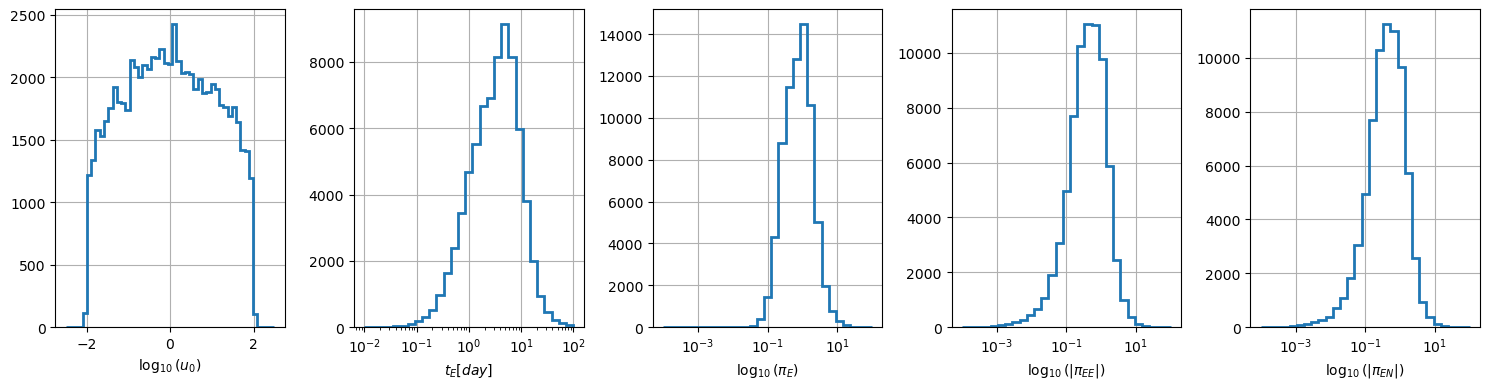

In [8]:

valid_data = true[param_names]
log_data = valid_data

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, param in enumerate(param_names):
    if param=='tE':
        axes[i].hist(log_data[param], bins=np.logspace(-2,2,30), histtype='step', linewidth=2)
        axes[i].set_xscale("log")
    elif (param=='piE'):
        axes[i].hist(log_data[param], bins=np.logspace(-4,2,30), histtype='step', linewidth=2)
        axes[i].set_xscale("log")

    elif (param=='piEE') or (param=='piEN'):
        axes[i].hist(abs(log_data[param]), bins=np.logspace(-4,2,30), histtype='step', linewidth=2)
        axes[i].set_xscale("log")
    
    elif param=='u0':
        axes[i].hist(log_data[param], bins=np.linspace(-2.5,2.5,50), histtype='step', linewidth=2)
    else: 
        axes[i].hist(log_data[param], bins=np.linspace(-1e-1,1e-1,50), histtype='step', linewidth=2)
    axes[i].set_xlabel(param_labels[i])
    axes[i].grid(True)
    
plt.tight_layout()
plt.show()